In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

report_path = Path("../output/unified_report.json")
with report_path.open() as f:
    report = json.load(f)

DIMS = ["accuracy", "completeness", "topic_coherence", "citation_quality"]

print(f"{len(report)} eval folders:")
for k in report:
    print(" -", k)

7 eval folders:
 - output/llama/eval_sft
 - output/llama/eval_hallucinate_citation
 - output/llama/eval_hallucinate_text
 - output/llama/eval_article_swap
 - output/llama/eval_law_swap
 - output/llama/eval_gr_dpo
 - output/llama/eval_dr_dpo


## Summary table

One row per eval folder: sample counts, judges used, overall scores, win rates, citation F1.

In [2]:
def corruption_name(key: str) -> str:
    return Path(key).name.replace("eval_", "")


rows = []
for key, r in report.items():
    js = r["judge_scores"]
    row = {
        "corruption": corruption_name(key),
        "n_questions": r["n_questions"],
        "n_judged": r["n_judged"],
        "n_judges": len(r["judges"]),
        "baseline_overall": js["baseline"]["overall"],
        "dpo_overall": js["dpo"]["overall"],
        "delta_overall": js["dpo"]["overall"] - js["baseline"]["overall"],
        "dpo_win_rate": r["win_rate"]["dpo"],
        "baseline_win_rate": r["win_rate"]["baseline"],
        "tie_rate": r["win_rate"]["tie"],
        "baseline_citation_f1": r["citation_f1"]["baseline"],
        "dpo_citation_f1": r["citation_f1"]["dpo"],
    }
    rows.append(row)

summary = pd.DataFrame(rows).set_index("corruption").sort_values("delta_overall", ascending=False)
summary.round(3)

,n_questions,n_judged,n_judges,baseline_overall,dpo_overall,delta_overall,dpo_win_rate,baseline_win_rate,tie_rate,baseline_citation_f1,dpo_citation_f1
corruption,,,,,,,,,,,
sft,100,100,3,1.959,2.282,0.323,0.66,0.24,0.10,0.245,0.181
dr_dpo,100,100,3,1.969,2.077,0.108,0.51,0.34,0.15,0.245,0.223
gr_dpo,100,100,3,1.967,2.055,0.088,0.48,0.37,0.15,0.245,0.229
law_swap,100,100,3,1.969,2.027,0.058,0.43,0.39,0.18,0.245,0.251
hallucinate_text,100,100,3,1.970,1.999,0.029,0.44,0.41,0.15,0.245,0.225
hallucinate_citation,100,100,3,1.971,1.992,0.022,0.45,0.38,0.17,0.245,0.230
article_swap,100,100,3,1.973,1.991,0.017,0.43,0.45,0.12,0.245,0.231


## Overall score: baseline vs. DPO, per corruption type

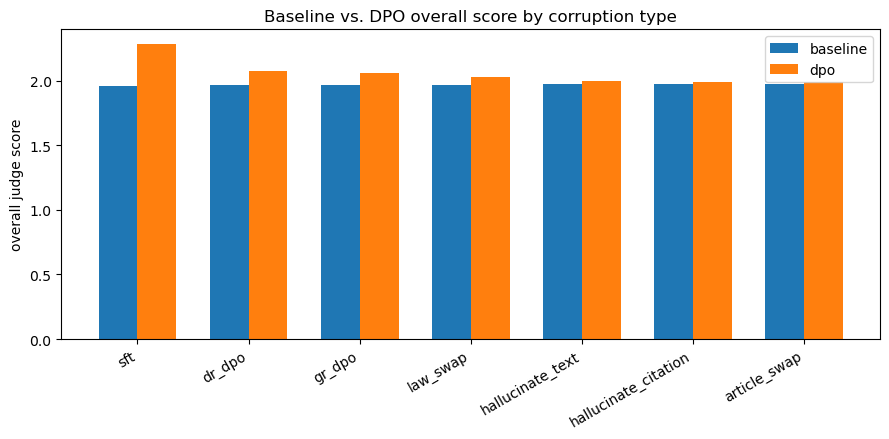

In [3]:
order = summary.index

fig, ax = plt.subplots(figsize=(9, 4.5))
x = range(len(order))
w = 0.35
ax.bar([i - w / 2 for i in x], summary.loc[order, "baseline_overall"], width=w, label="baseline")
ax.bar([i + w / 2 for i in x], summary.loc[order, "dpo_overall"], width=w, label="dpo")
ax.set_xticks(list(x))
ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylabel("overall judge score")
ax.set_title("Baseline vs. DPO overall score by corruption type")
ax.legend()
fig.tight_layout()
plt.show()

## Per-dimension breakdown

Long-form table (corruption × model × dimension) and a heatmap of the DPO−baseline gap.

In [4]:
dim_rows = []
for key, r in report.items():
    name = corruption_name(key)
    for model_key in ("baseline", "dpo"):
        for d in DIMS:
            dim_rows.append(
                {
                    "corruption": name,
                    "model": model_key,
                    "dimension": d,
                    "score": r["judge_scores"][model_key][d],
                }
            )

dim_long = pd.DataFrame(dim_rows)

gap = (
    dim_long.pivot_table(index="corruption", columns=["dimension", "model"], values="score")
    .reindex(order)
)
# DPO - baseline gap per dimension
gap_diff = pd.DataFrame(
    {d: gap[d]["dpo"] - gap[d]["baseline"] for d in DIMS}
)
gap_diff.round(3)

,accuracy,completeness,topic_coherence,citation_quality
corruption,,,,
sft,0.024,0.321,0.526,0.422
dr_dpo,0.049,0.087,0.262,0.033
gr_dpo,0.046,0.062,0.241,0.001
law_swap,-0.022,0.015,0.233,0.004
hallucinate_text,-0.052,-0.029,0.198,-0.001
hallucinate_citation,-0.050,0.016,0.216,-0.096
article_swap,-0.065,0.011,0.128,-0.004


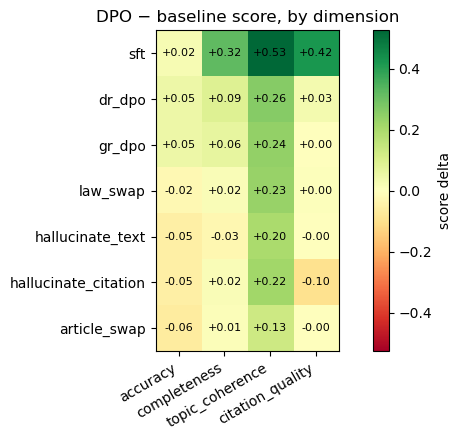

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(gap_diff.values, cmap="RdYlGn", vmin=-gap_diff.abs().max().max(), vmax=gap_diff.abs().max().max())
ax.set_xticks(range(len(DIMS)))
ax.set_xticklabels(DIMS, rotation=30, ha="right")
ax.set_yticks(range(len(gap_diff.index)))
ax.set_yticklabels(gap_diff.index)
for i in range(gap_diff.shape[0]):
    for j in range(gap_diff.shape[1]):
        ax.text(j, i, f"{gap_diff.values[i, j]:+.2f}", ha="center", va="center", fontsize=8)
ax.set_title("DPO − baseline score, by dimension")
fig.colorbar(im, ax=ax, label="score delta")
fig.tight_layout()
plt.show()

## Win rate (pairwise judge preference)

/var/folders/nc/8j1ss2cd235bsvjlnf8yw7c40000gn/T/ipykernel_57219/2011665957.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order, rotation=30, ha="right")


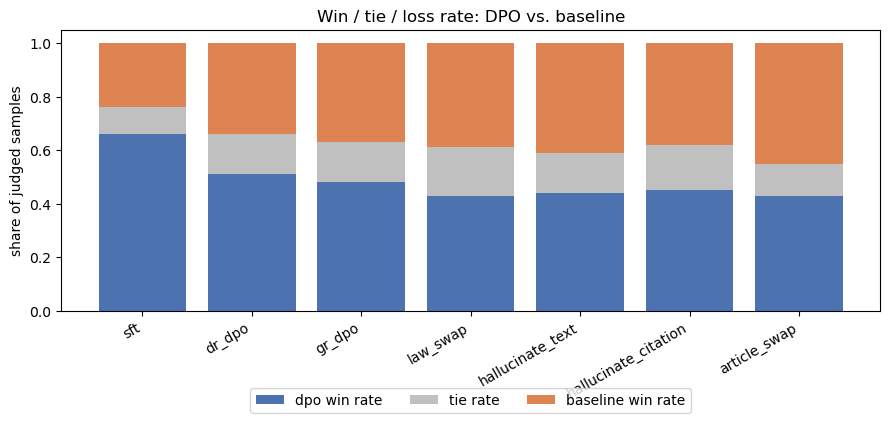

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.5))
bottom = [0] * len(order)
for label, color in [("dpo_win_rate", "#4c72b0"), ("tie_rate", "#c0c0c0"), ("baseline_win_rate", "#dd8452")]:
    vals = summary.loc[order, label]
    ax.bar(order, vals, bottom=bottom, label=label.replace("_", " "), color=color)
    bottom = [b + v for b, v in zip(bottom, vals)]
ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylabel("share of judged samples")
ax.set_title("Win / tie / loss rate: DPO vs. baseline")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.25), ncol=3)
fig.tight_layout()
plt.show()

## Citation F1 (span-overlap, not judge-based)

Note this is computed independently of the LLM judges via `citation_parser.find_citation_spans`,
so it can disagree with the judges' `citation_quality` dimension above.

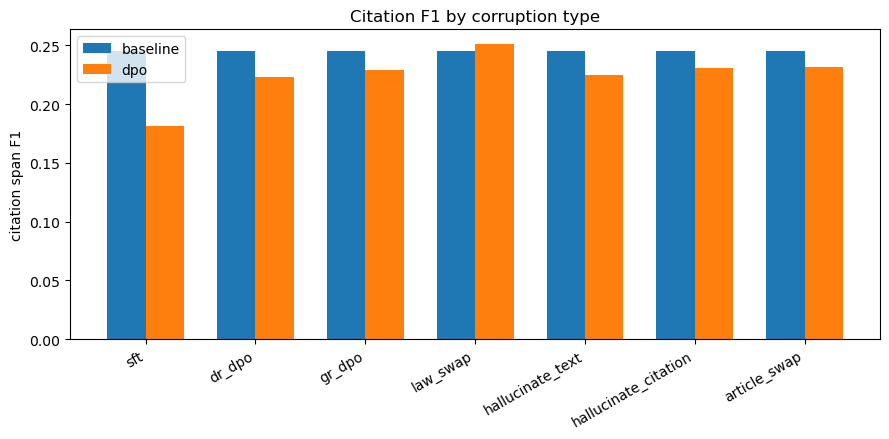

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))
x = range(len(order))
w = 0.35
ax.bar([i - w / 2 for i in x], summary.loc[order, "baseline_citation_f1"], width=w, label="baseline")
ax.bar([i + w / 2 for i in x], summary.loc[order, "dpo_citation_f1"], width=w, label="dpo")
ax.set_xticks(list(x))
ax.set_xticklabels(order, rotation=30, ha="right")
ax.set_ylabel("citation span F1")
ax.set_title("Citation F1 by corruption type")
ax.legend()
fig.tight_layout()
plt.show()

## Judge consistency across eval folders

`unified_report.py` normalizes judge names via `canonical_judge` before aggregating (since the
same served model was registered under different endpoint names across runs). Check whether every
folder ended up judged by the same canonical judge set.

In [8]:
judge_sets = {corruption_name(k): set(r["judges"]) for k, r in report.items()}
all_judges = sorted(set().union(*judge_sets.values()))

presence = pd.DataFrame(
    {name: {j: (j in judges) for j in all_judges} for name, judges in judge_sets.items()}
).T
presence.columns.name = "judge"
presence

judge,CSCS-Inference/google/gemma-4-31B-it,RCP-AIaaS/Qwen/Qwen3.6-35B-A3B,RCP-AIaaS/zai-org/GLM-5.3-Flash
sft,True,True,True
hallucinate_citation,True,True,True
hallucinate_text,True,True,True
article_swap,True,True,True
law_swap,True,True,True
gr_dpo,True,True,True
dr_dpo,True,True,True


## Digging into the SFT win-rate vs. citation-F1 divergence

For `eval_sft`, judges strongly prefer the trained ("dpo"-keyed) model (66% win rate, higher
`citation_quality`), yet its `citation_f1` is *lower* than baseline's. Two hypotheses:

1. **Real effect** — the trained model cites more aggressively (more spans per answer), which
   hurts F1 precision even though judges reward the apparent thoroughness.
2. **Metric artifact** — `unified_report.citation_f1` compares *raw substrings* from
   `find_citation_spans` (e.g. `"art. 422(2)"` vs `"article 422(2)"` are different strings), while
   `citation_parser.extract_citations` + `Citation.full_key()` already do proper normalization
   (acronym resolution, instrument/article/paragraph canonicalization). If a lot of the F1 loss is
   just formatting variance, normalizing should close much of the gap.

We check both below.

In [9]:
from citation_parser import extract_citations, find_citation_spans


def raw_spans(text: str) -> set[str]:
    """Same extraction unified_report.citation_f1 uses: lowercased raw substrings."""
    return {text[s:e].lower().strip() for s, e, *_ in find_citation_spans(text)}


def norm_spans(text: str) -> set[str]:
    """Normalized keys via Citation.full_key() (acronym/article/paragraph canonicalized)."""
    return {c.full_key() for c in extract_citations(text) if c.full_key()}


def f1(pred: set[str], ref: set[str]) -> float | None:
    if not ref and not pred:
        return 1.0
    if not ref or not pred:
        return 0.0
    tp = len(pred & ref)
    p, r = tp / len(pred), tp / len(ref)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0


def load_jsonl(path: Path) -> list[dict]:
    with path.open() as f:
        return [json.loads(l) for l in f if l.strip()]


row_records = []
for key_path in report:
    folder = Path("..") / key_path
    name = corruption_name(key_path)
    answers = load_jsonl(folder / "eval_answers.jsonl")
    for row in answers:
        ref = row.get("ground_truth", "")
        ref_raw, ref_norm = raw_spans(ref), norm_spans(ref)
        for model_key in ("baseline", "dpo"):
            pred = row.get(model_key, {}).get("text", "")
            if not pred:
                continue
            pred_raw, pred_norm = raw_spans(pred), norm_spans(pred)
            row_records.append(
                {
                    "corruption": name,
                    "question_id": row["question_id"],
                    "model": model_key,
                    "n_pred_citations": len(pred_raw),
                    "n_ref_citations": len(ref_raw),
                    "raw_f1": f1(pred_raw, ref_raw),
                    "norm_f1": f1(pred_norm, ref_norm),
                }
            )

row_df = pd.DataFrame(row_records)
row_df.head()

,corruption,question_id,model,n_pred_citations,n_ref_citations,raw_f1,norm_f1
0,sft,EBA_2013_557,baseline,2,5,0.0,0.000000
1,sft,EBA_2013_557,dpo,5,5,0.2,0.222222
2,sft,EBA_2014_1090,baseline,2,0,0.0,0.000000
3,sft,EBA_2014_1090,dpo,2,0,0.0,0.000000
4,sft,EBA_2015_2217,baseline,0,0,1.0,1.000000


In [10]:
f1_compare = (
    row_df.groupby(["corruption", "model"])[["raw_f1", "norm_f1", "n_pred_citations"]]
    .mean()
    .unstack("model")
    .reindex(order)
)
f1_compare.round(3)

raw_f1         norm_f1        n_pred_citations      
model                baseline    dpo baseline    dpo         baseline   dpo
corruption                                                                 
sft                     0.245  0.181    0.266  0.187             1.96  5.11
dr_dpo                  0.245  0.223    0.266  0.244             1.96  1.93
gr_dpo                  0.245  0.229    0.266  0.241             1.96  1.79
law_swap                0.245  0.251    0.266  0.270             1.96  1.65
hallucinate_text        0.245  0.225    0.266  0.241             1.96  1.85
hallucinate_citation    0.245  0.230    0.266  0.255             1.96  1.76
article_swap            0.245  0.231    0.266  0.250             1.96  1.82

## Per-row: judge `citation_quality` vs. `raw_f1`

Join each row's citation F1 with its (canonical-judge-averaged) `citation_quality` score, to see
whether the two metrics actually disagree at the row level or whether the aggregate gap is driven
by a handful of outliers.

In [11]:
from eval_dpo import canonical_judge

cq_records = []
for key_path in report:
    folder = Path("..") / key_path
    name = corruption_name(key_path)
    scored = load_jsonl(folder / "eval_judge_scores.jsonl")
    for row in scored:
        for model_key in ("baseline", "dpo"):
            vals = [
                sc["citation_quality"]
                for raw_judge, sc in row["scores"].get(model_key, {}).items()
                if sc.get("citation_quality") is not None
            ]
            if vals:
                cq_records.append(
                    {
                        "corruption": name,
                        "question_id": row["question_id"],
                        "model": model_key,
                        "citation_quality": sum(vals) / len(vals),
                    }
                )

cq_df = pd.DataFrame(cq_records)
joined = row_df.merge(cq_df, on=["corruption", "question_id", "model"], how="inner")

corr_by_group = joined.groupby(["corruption", "model"]).apply(
    lambda g: g["raw_f1"].corr(g["citation_quality"]), include_groups=False
)
corr_by_group.unstack("model").reindex(order).round(3)

model,baseline,dpo
corruption,,
sft,0.110,0.270
dr_dpo,0.102,0.052
gr_dpo,0.101,0.084
law_swap,0.101,0.094
hallucinate_text,0.096,0.033
hallucinate_citation,0.099,0.149
article_swap,0.101,0.060


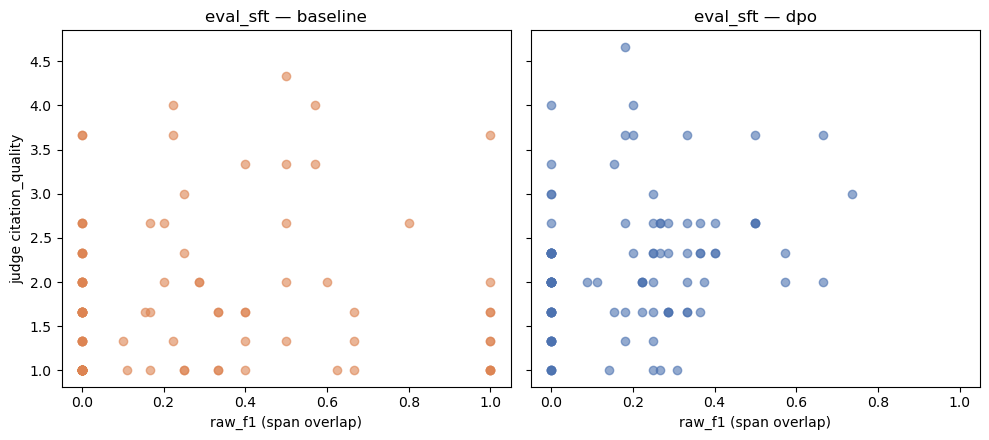

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True, sharex=True)
for ax, model_key, color in zip(axes, ("baseline", "dpo"), ("#dd8452", "#4c72b0")):
    sub = joined[(joined["corruption"] == "sft") & (joined["model"] == model_key)]
    ax.scatter(sub["raw_f1"], sub["citation_quality"], alpha=0.6, color=color)
    ax.set_title(f"eval_sft — {model_key}")
    ax.set_xlabel("raw_f1 (span overlap)")
axes[0].set_ylabel("judge citation_quality")
fig.tight_layout()
plt.show()

In [13]:
# Rows where SFT ("dpo") scores near-zero on raw_f1 but judges still rate citation_quality high —
# the clearest cases of the divergence.
sft_dpo = joined[(joined["corruption"] == "sft") & (joined["model"] == "dpo")]
worst = sft_dpo[(sft_dpo["raw_f1"] < 0.1) & (sft_dpo["citation_quality"] >= 3)].sort_values(
    "citation_quality", ascending=False
)
print(f"{len(worst)} / {len(sft_dpo)} rows: raw_f1 < 0.1 but citation_quality >= 3")
worst[["question_id", "raw_f1", "n_pred_citations", "n_ref_citations", "citation_quality"]].head(10)

4 / 100 rows: raw_f1 < 0.1 but citation_quality >= 3


,question_id,raw_f1,n_pred_citations,n_ref_citations,citation_quality
177,EBA_2015_2283,0.0,3,1,4.000000
159,EBA_2021_5819,0.0,4,0,3.333333
7,EBA_2019_4985,0.0,7,2,3.000000
69,EBA_2024_7006,0.0,4,0,3.000000


## Paired bootstrap CI for citation F1 (baseline vs. trained model)

All eval folders share the same 100 question IDs, and `baseline` is the same underlying model's
answers repeated across folders — so this is a genuine paired design: for every question we have
`(baseline_f1, dpo_f1)` under the same corruption fold. We resample question indices with
replacement (same resampled indices applied to both arrays, preserving the pairing), recompute the
mean delta each time, and take the 2.5/97.5 percentiles as the 95% CI. The bootstrap p-value is the
two-sided fraction of resamples on the wrong side of zero.

In [14]:
import numpy as np

rng = np.random.default_rng(0)
N_BOOT = 10_000


def paired_bootstrap_ci(baseline: np.ndarray, treated: np.ndarray, n_boot: int = N_BOOT, seed: int = 0):
    """95% CI + two-sided bootstrap p-value for mean(treated - baseline), question-paired resampling."""
    assert len(baseline) == len(treated)
    n = len(baseline)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_boot, n))
    deltas = treated[idx].mean(axis=1) - baseline[idx].mean(axis=1)
    point = treated.mean() - baseline.mean()
    lo, hi = np.percentile(deltas, [2.5, 97.5])
    # two-sided p-value: fraction of resamples that cross zero, mirrored around the observed sign
    p = 2 * min((deltas <= 0).mean(), (deltas > 0).mean())
    return point, lo, hi, min(p, 1.0)


boot_rows = []
for name in order:
    sub = row_df[row_df["corruption"] == name]
    b = sub[sub["model"] == "baseline"].sort_values("question_id")["raw_f1"].to_numpy()
    d = sub[sub["model"] == "dpo"].sort_values("question_id")["raw_f1"].to_numpy()
    point, lo, hi, p = paired_bootstrap_ci(b, d)
    boot_rows.append(
        {
            "corruption": name,
            "n": len(b),
            "delta_f1": point,
            "ci_lo": lo,
            "ci_hi": hi,
            "p_boot": p,
            "significant_95": (lo > 0) or (hi < 0),
        }
    )

boot_df = pd.DataFrame(boot_rows).set_index("corruption")
boot_df.round(4)

,n,delta_f1,ci_lo,ci_hi,p_boot,significant_95
corruption,,,,,,
sft,100,-0.0641,-0.1399,0.0055,0.0708,False
dr_dpo,100,-0.0221,-0.0623,0.0152,0.2456,False
gr_dpo,100,-0.0163,-0.0657,0.0313,0.4990,False
law_swap,100,0.0060,-0.0248,0.0372,0.6892,False
hallucinate_text,100,-0.0201,-0.0592,0.0167,0.2884,False
hallucinate_citation,100,-0.0146,-0.0518,0.0199,0.4220,False
article_swap,100,-0.0138,-0.0460,0.0186,0.3870,False


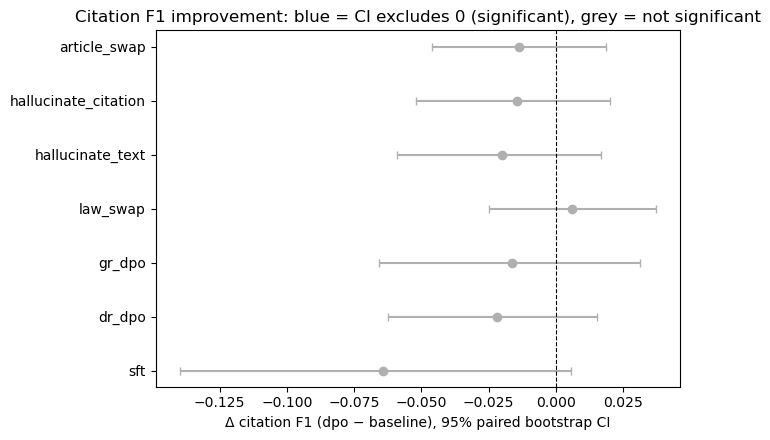

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
y = list(range(len(boot_df)))
colors = ["#4c72b0" if sig else "#b0b0b0" for sig in boot_df["significant_95"]]
for yi, (_, row), color in zip(y, boot_df.iterrows(), colors):
    ax.errorbar(
        row["delta_f1"],
        yi,
        xerr=[[row["delta_f1"] - row["ci_lo"]], [row["ci_hi"] - row["delta_f1"]]],
        fmt="o",
        color=color,
        capsize=3,
    )
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(boot_df.index)
ax.set_xlabel("Δ citation F1 (dpo − baseline), 95% paired bootstrap CI")
ax.set_title("Citation F1 improvement: blue = CI excludes 0 (significant), grey = not significant")
fig.tight_layout()
plt.show()

## Re-basing: SFT as baseline instead of the raw model

Above, `baseline` = the untrained model, repeated across every fold. That answers "does DPO beat
no-training-at-all." A different (arguably more relevant) question is "does DPO add anything on
top of SFT" — i.e. is DPO training worth it given you already did preference-only SFT?

To test that, rebase: use `eval_sft`'s trained-model column as the baseline array, and diff every
other fold's DPO-trained column against it, matched by `question_id` (safe since every folder
shares the same 100 questions). Same paired-bootstrap machinery as before.

In [16]:
# SFT-trained model's per-question citation F1, as the new baseline array
sft_f1 = (
    row_df[(row_df["corruption"] == "sft") & (row_df["model"] == "dpo")]
    .sort_values("question_id")
    .set_index("question_id")["raw_f1"]
)

# same rebase for judge citation_quality, using the row-level join built earlier
sft_cq = (
    joined[(joined["corruption"] == "sft") & (joined["model"] == "dpo")]
    .sort_values("question_id")
    .set_index("question_id")["citation_quality"]
)

rebased_rows = []
for name in order:
    if name == "sft":
        continue  # nothing to rebase SFT against itself
    sub_f1 = (
        row_df[(row_df["corruption"] == name) & (row_df["model"] == "dpo")]
        .sort_values("question_id")
        .set_index("question_id")["raw_f1"]
    )
    b_f1, t_f1 = sft_f1.align(sub_f1)  # aligned on shared question_id, same order
    point, lo, hi, p = paired_bootstrap_ci(b_f1.to_numpy(), t_f1.to_numpy())
    rebased_rows.append(
        {
            "corruption": name,
            "n": len(b_f1),
            "delta_f1_vs_sft": point,
            "ci_lo": lo,
            "ci_hi": hi,
            "p_boot": p,
            "significant_95": (lo > 0) or (hi < 0),
        }
    )

rebased_df = pd.DataFrame(rebased_rows).set_index("corruption")
rebased_df.round(4)

,n,delta_f1_vs_sft,ci_lo,ci_hi,p_boot,significant_95
corruption,,,,,,
dr_dpo,100,0.0420,-0.0252,0.1155,0.2460,False
gr_dpo,100,0.0478,-0.0222,0.1243,0.2022,False
law_swap,100,0.0701,0.0018,0.1450,0.0440,True
hallucinate_text,100,0.0441,-0.0231,0.1181,0.2200,False
hallucinate_citation,100,0.0496,-0.0175,0.1227,0.1638,False
article_swap,100,0.0503,-0.0187,0.1255,0.1700,False


Same rebase for judge `overall` score, since that's the other headline number.

In [17]:
from eval_dpo import canonical_judge as _canon  # noqa: F401 (already imported above, kept explicit here)

overall_records = []
for key_path in report:
    folder = Path("..") / key_path
    name = corruption_name(key_path)
    scored = load_jsonl(folder / "eval_judge_scores.jsonl")
    for row in scored:
        for model_key in ("baseline", "dpo"):
            per_judge_means = []
            for raw_judge, sc in row["scores"].get(model_key, {}).items():
                vs = [sc.get(d) for d in DIMS if sc.get(d) is not None]
                if vs:
                    per_judge_means.append(sum(vs) / len(vs))
            if per_judge_means:
                overall_records.append(
                    {
                        "corruption": name,
                        "question_id": row["question_id"],
                        "model": model_key,
                        "overall": sum(per_judge_means) / len(per_judge_means),
                    }
                )

overall_df = pd.DataFrame(overall_records)

sft_overall = (
    overall_df[(overall_df["corruption"] == "sft") & (overall_df["model"] == "dpo")]
    .sort_values("question_id")
    .set_index("question_id")["overall"]
)

rebased_overall_rows = []
for name in order:
    if name == "sft":
        continue
    sub = (
        overall_df[(overall_df["corruption"] == name) & (overall_df["model"] == "dpo")]
        .sort_values("question_id")
        .set_index("question_id")["overall"]
    )
    b, t = sft_overall.align(sub)
    point, lo, hi, p = paired_bootstrap_ci(b.to_numpy(), t.to_numpy())
    rebased_overall_rows.append(
        {
            "corruption": name,
            "n": len(b),
            "delta_overall_vs_sft": point,
            "ci_lo": lo,
            "ci_hi": hi,
            "p_boot": p,
            "significant_95": (lo > 0) or (hi < 0),
        }
    )

rebased_overall_df = pd.DataFrame(rebased_overall_rows).set_index("corruption")
rebased_overall_df.round(4)

,n,delta_overall_vs_sft,ci_lo,ci_hi,p_boot,significant_95
corruption,,,,,,
dr_dpo,100,-0.2096,-0.3588,-0.0588,0.0072,True
gr_dpo,100,-0.2250,-0.3675,-0.0792,0.0026,True
law_swap,100,-0.2542,-0.4033,-0.0992,0.0008,True
hallucinate_text,100,-0.2800,-0.4225,-0.1350,0.0000,True
hallucinate_citation,100,-0.2817,-0.4333,-0.1308,0.0000,True
article_swap,100,-0.2896,-0.4317,-0.1417,0.0004,True


Same rebase (SFT as baseline) for the judge `accuracy` dimension specifically.

In [18]:
def per_row_dim_scores(dimension: str) -> pd.DataFrame:
    records = []
    for key_path in report:
        folder = Path("..") / key_path
        name = corruption_name(key_path)
        scored = load_jsonl(folder / "eval_judge_scores.jsonl")
        for row in scored:
            for model_key in ("baseline", "dpo"):
                vals = [
                    sc.get(dimension)
                    for raw_judge, sc in row["scores"].get(model_key, {}).items()
                    if sc.get(dimension) is not None
                ]
                if vals:
                    records.append(
                        {
                            "corruption": name,
                            "question_id": row["question_id"],
                            "model": model_key,
                            dimension: sum(vals) / len(vals),
                        }
                    )
    return pd.DataFrame(records)


accuracy_df = per_row_dim_scores("accuracy")

sft_accuracy = (
    accuracy_df[(accuracy_df["corruption"] == "sft") & (accuracy_df["model"] == "dpo")]
    .sort_values("question_id")
    .set_index("question_id")["accuracy"]
)

rebased_accuracy_rows = []
for name in order:
    if name == "sft":
        continue
    sub = (
        accuracy_df[(accuracy_df["corruption"] == name) & (accuracy_df["model"] == "dpo")]
        .sort_values("question_id")
        .set_index("question_id")["accuracy"]
    )
    b, t = sft_accuracy.align(sub)
    point, lo, hi, p = paired_bootstrap_ci(b.to_numpy(), t.to_numpy())
    rebased_accuracy_rows.append(
        {
            "corruption": name,
            "n": len(b),
            "delta_accuracy_vs_sft": point,
            "ci_lo": lo,
            "ci_hi": hi,
            "p_boot": p,
            "significant_95": (lo > 0) or (hi < 0),
        }
    )

rebased_accuracy_df = pd.DataFrame(rebased_accuracy_rows).set_index("corruption")
rebased_accuracy_df.round(4)

,n,delta_accuracy_vs_sft,ci_lo,ci_hi,p_boot,significant_95
corruption,,,,,,
dr_dpo,100,0.0167,-0.1700,0.2167,0.8792,False
gr_dpo,100,0.0167,-0.1833,0.2267,0.8884,False
law_swap,100,-0.0500,-0.2400,0.1501,0.6014,False
hallucinate_text,100,-0.0800,-0.2700,0.1233,0.4242,False
hallucinate_citation,100,-0.0700,-0.2567,0.1267,0.4752,False
article_swap,100,-0.0883,-0.2667,0.1033,0.3508,False


## Null judge scores, per file and per judge

Some judge calls fail to produce a parseable score (all four dimensions come back `None` together
— never a partial null, always the whole row for that judge/model). Count these per corruption
folder and per canonical judge, out of 200 possible entries per judge per folder (100 questions ×
2 models).

In [19]:
null_records = []
for key_path in report:
    folder = Path("..") / key_path
    name = corruption_name(key_path)
    scored = load_jsonl(folder / "eval_judge_scores.jsonl")
    for row in scored:
        for model_key in ("baseline", "dpo"):
            for raw_judge, sc in row["scores"].get(model_key, {}).items():
                jm = canonical_judge(raw_judge)
                n_null = sum(1 for d in DIMS if sc.get(d) is None)
                null_records.append(
                    {
                        "corruption": name,
                        "judge": jm,
                        "model": model_key,
                        "question_id": row["question_id"],
                        "n_null_dims": n_null,
                        "fully_null": n_null == len(DIMS),
                    }
                )

null_df = pd.DataFrame(null_records)

# sanity check: nulls are always all-4-dims-at-once, never partial
partial = null_df[(null_df["n_null_dims"] > 0) & (~null_df["fully_null"])]
print(f"partial-null entries (some but not all dims None): {len(partial)}")

null_counts = (
    null_df.groupby(["corruption", "judge"])["fully_null"]
    .sum()
    .unstack("judge")
    .reindex(order)
    .fillna(0)
    .astype(int)
)
null_counts["total"] = null_counts.sum(axis=1)
null_counts

partial-null entries (some but not all dims None): 0


judge,CSCS-Inference/google/gemma-4-31B-it,RCP-AIaaS/Qwen/Qwen3.6-35B-A3B,RCP-AIaaS/zai-org/GLM-5.3-Flash,total
corruption,,,,
sft,0,0,0,0
dr_dpo,0,0,1,1
gr_dpo,0,0,1,1
law_swap,0,0,0,0
hallucinate_text,0,0,0,0
hallucinate_citation,0,0,0,0
article_swap,0,0,1,1


In [20]:
# null rate as % of 200 possible entries per judge per folder (100 questions x baseline/dpo)
null_rate = null_counts.drop(columns="total") / 200 * 100
null_rate.round(1)

judge,CSCS-Inference/google/gemma-4-31B-it,RCP-AIaaS/Qwen/Qwen3.6-35B-A3B,RCP-AIaaS/zai-org/GLM-5.3-Flash
corruption,,,
sft,0.0,0.0,0.0
dr_dpo,0.0,0.0,0.5
gr_dpo,0.0,0.0,0.5
law_swap,0.0,0.0,0.0
hallucinate_text,0.0,0.0,0.0
hallucinate_citation,0.0,0.0,0.0
article_swap,0.0,0.0,0.5


In [21]:
# split by model (baseline vs. dpo) to see whether nulls concentrate on one side
null_by_model = (
    null_df.groupby(["corruption", "judge", "model"])["fully_null"]
    .sum()
    .unstack("model")
    .reindex(order, level="corruption")
    .fillna(0)
    .astype(int)
)
null_by_model[(null_by_model["baseline"] > 0) | (null_by_model["dpo"] > 0)]

,model,baseline,dpo
corruption,judge,,
dr_dpo,RCP-AIaaS/zai-org/GLM-5.3-Flash,0,1
gr_dpo,RCP-AIaaS/zai-org/GLM-5.3-Flash,1,0
article_swap,RCP-AIaaS/zai-org/GLM-5.3-Flash,0,1


## Paired bootstrap CI for judge `overall` score (raw baseline, per fold)

Same design as the original `boot_df` for citation F1, but on the judge `overall` score, using
each fold's own untrained `baseline` column (not the SFT rebase from before) — i.e. does each
trained variant (sft, dr_dpo, gr_dpo, and the four corruption-specific DPO runs) beat the raw
model it was evaluated against in that same fold. Reuses `overall_df` (built earlier for the SFT
rebase — now reflecting the re-judged, null-fixed scores) and the same `paired_bootstrap_ci`
helper.

In [22]:
boot_overall_rows = []
for name in order:
    sub = overall_df[overall_df["corruption"] == name]
    b = sub[sub["model"] == "baseline"].sort_values("question_id")["overall"].to_numpy()
    d = sub[sub["model"] == "dpo"].sort_values("question_id")["overall"].to_numpy()
    point, lo, hi, p = paired_bootstrap_ci(b, d)
    boot_overall_rows.append(
        {
            "corruption": name,
            "n": len(b),
            "baseline_mean": b.mean(),
            "trained_mean": d.mean(),
            "delta_overall": point,
            "ci_lo": lo,
            "ci_hi": hi,
            "p_boot": p,
            "significant_95": (lo > 0) or (hi < 0),
        }
    )

boot_overall_df = pd.DataFrame(boot_overall_rows).set_index("corruption")
boot_overall_df.round(4)

,n,baseline_mean,trained_mean,delta_overall,ci_lo,ci_hi,p_boot,significant_95
corruption,,,,,,,,
sft,100,1.9592,2.2808,0.3217,0.1650,0.4725,0.0000,True
dr_dpo,100,1.9725,2.0712,0.0987,-0.0117,0.2071,0.0780,False
gr_dpo,100,1.9704,2.0558,0.0854,-0.0700,0.2292,0.2750,False
law_swap,100,1.9733,2.0267,0.0533,-0.0383,0.1458,0.2642,False
hallucinate_text,100,1.9742,2.0008,0.0267,-0.0542,0.1067,0.5202,False
hallucinate_citation,100,1.9725,1.9992,0.0267,-0.0650,0.1183,0.5842,False
article_swap,100,1.9733,1.9912,0.0179,-0.0708,0.1042,0.6882,False


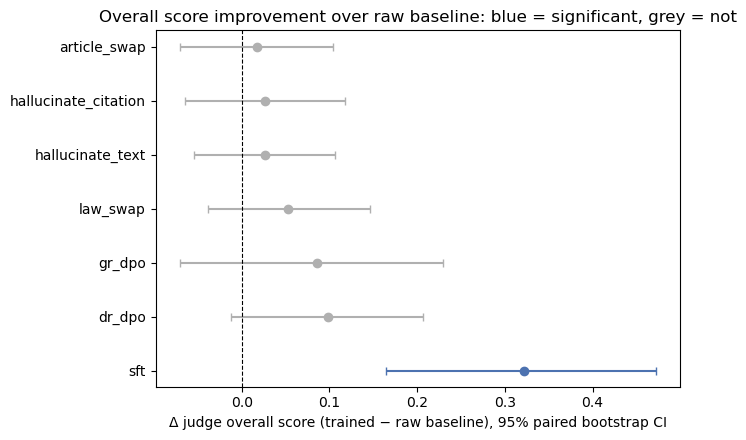

In [23]:
fig, ax = plt.subplots(figsize=(7, 4.5))
y = list(range(len(boot_overall_df)))
colors = ["#4c72b0" if sig else "#b0b0b0" for sig in boot_overall_df["significant_95"]]
for yi, (_, row), color in zip(y, boot_overall_df.iterrows(), colors):
    ax.errorbar(
        row["delta_overall"],
        yi,
        xerr=[[row["delta_overall"] - row["ci_lo"]], [row["ci_hi"] - row["delta_overall"]]],
        fmt="o",
        color=color,
        capsize=3,
    )
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_yticks(y)
ax.set_yticklabels(boot_overall_df.index)
ax.set_xlabel("Δ judge overall score (trained − raw baseline), 95% paired bootstrap CI")
ax.set_title("Overall score improvement over raw baseline: blue = significant, grey = not")
fig.tight_layout()
plt.show()

In [24]:
0.18-0.22

-0.04000000000000001

# Unified Report — Data Exploration

Explores `output/unified_report.json`, produced by `script/unified_report.py`.
Each key is a corruption/eval folder (e.g. `eval_hallucinate_citation`), holding
judge-averaged scores for `baseline` vs `dpo` across four dimensions
(accuracy, completeness, topic_coherence, citation_quality), win rates, and
citation F1.